# Home Assignment 5: Планирование пути (Path Planning)

**Цель:** Реализовать конвейер поиска пути в 2D пространстве, сравнив классический A\* с алгоритмами на основе случайного сэмплирования (RRT / RRT\*), и выполнить постобработку траектории.

**Алгоритмы:**
1. A\* — оптимальный поиск на сетке
2. RRT — Rapidly-exploring Random Tree
3. RRT\* — модификация с перестроением дерева
4. Path Smoothing — сглаживание Безье-кривыми и градиентное сглаживание

**Справочник:** [AtsushiSakai/PythonRobotics](https://github.com/AtsushiSakai/PythonRobotics)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from matplotlib import animation
from IPython.display import HTML, Image
import heapq
import math
import random
import time
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
np.random.seed(42)
random.seed(42)

# Стиль графиков
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print("Все библиотеки импортированы успешно!")

Все библиотеки импортированы успешно!


## 1. Генерация карт (Occupancy Grids)

Создадим несколько карт разной сложности:
- **Простая карта** — базовые прямоугольные препятствия
- **Карта с узким коридором** — для демонстрации проблем RRT
- **Сложный лабиринт** — для полноценного сравнения алгоритмов

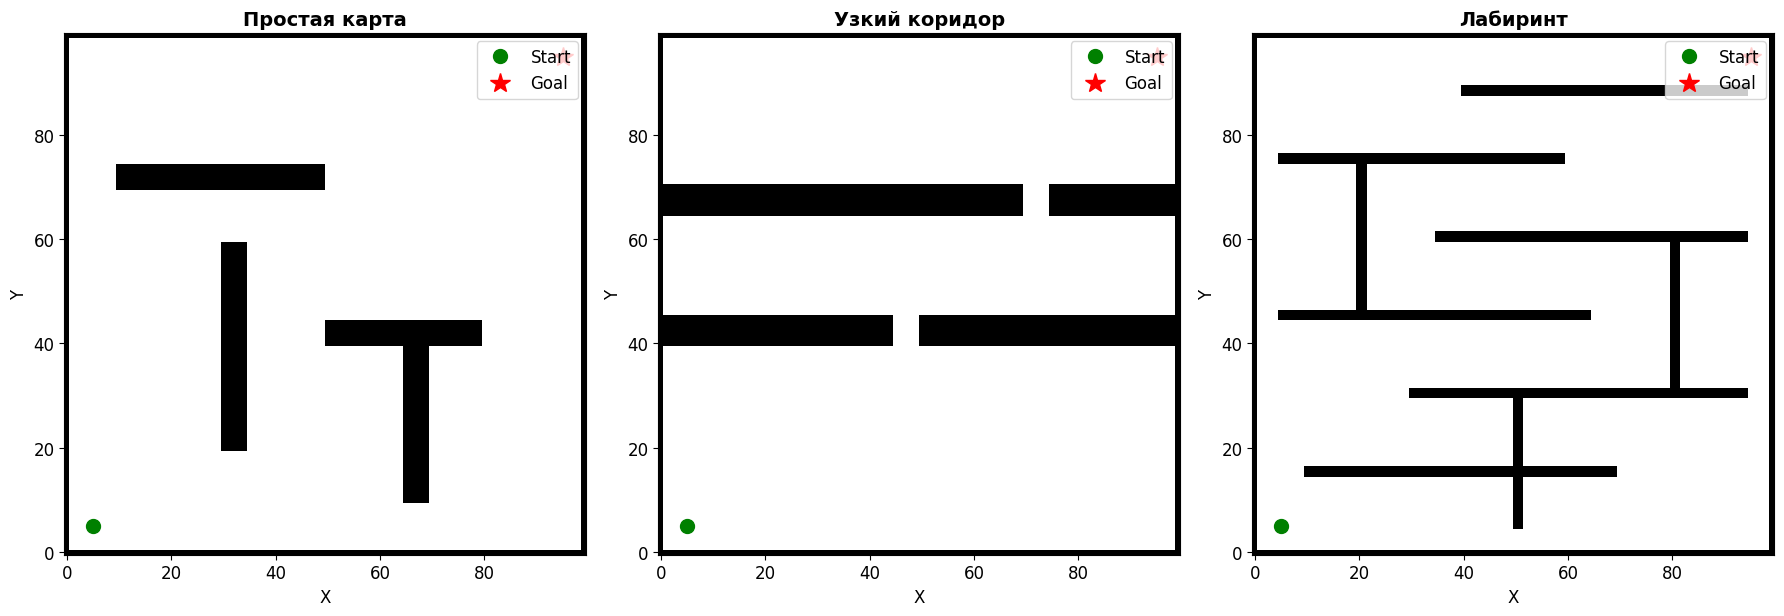

Карты сохранены в maps_overview.png


In [2]:
def create_simple_map(size=100):
    """Простая карта с прямоугольными препятствиями"""
    grid = np.zeros((size, size), dtype=np.uint8)

    # Границы
    grid[0, :] = 1
    grid[-1, :] = 1
    grid[:, 0] = 1
    grid[:, -1] = 1

    # Препятствия — стены
    grid[20:60, 30:35] = 1     # вертикальная стена
    grid[40:45, 50:80] = 1     # горизонтальная стена
    grid[70:75, 10:50] = 1     # горизонтальная стена снизу
    grid[10:40, 65:70] = 1     # вертикальная стена справа

    return grid

def create_narrow_corridor_map(size=100):
    """Карта с узким коридором — проблематична для RRT"""
    grid = np.zeros((size, size), dtype=np.uint8)

    # Границы
    grid[0, :] = 1
    grid[-1, :] = 1
    grid[:, 0] = 1
    grid[:, -1] = 1

    # Верхняя стена с узким проходом
    grid[40:46, :45] = 1
    grid[40:46, 50:] = 1    # проход 5 клеток шириной

    # Нижняя стена с узким проходом в другом месте
    grid[65:71, :70] = 1
    grid[65:71, 75:] = 1

    return grid

def create_maze_map(size=100):
    """Сложная карта-лабиринт"""
    grid = np.zeros((size, size), dtype=np.uint8)

    # Границы
    grid[0, :] = 1
    grid[-1, :] = 1
    grid[:, 0] = 1
    grid[:, -1] = 1

    # Лабиринтные стены
    grid[15:17, 10:70] = 1
    grid[30:32, 30:95] = 1
    grid[45:47, 5:65] = 1
    grid[60:62, 35:95] = 1
    grid[75:77, 5:60] = 1
    grid[88:90, 40:95] = 1

    # Вертикальные перегородки
    grid[5:30, 50:52] = 1
    grid[47:75, 20:22] = 1
    grid[32:60, 80:82] = 1

    return grid

# Создаём карты
maps = {
    'Простая карта': create_simple_map(),
    'Узкий коридор': create_narrow_corridor_map(),
    'Лабиринт': create_maze_map()
}

# Точки старта и финиша для каждой карты
start_goal = {
    'Простая карта': ((5, 5), (95, 95)),
    'Узкий коридор': ((5, 5), (95, 95)),
    'Лабиринт': ((5, 5), (95, 95))
}

# Визуализация карт
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, grid) in zip(axes, maps.items()):
    s, g = start_goal[name]
    ax.imshow(grid, cmap='gray_r', origin='lower')
    ax.plot(s[1], s[0], 'go', markersize=10, label='Start')
    ax.plot(g[1], g[0], 'r*', markersize=15, label='Goal')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
plt.tight_layout()
plt.savefig('maps_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Карты сохранены в maps_overview.png")

## 2. Реализация A\*

A\* — классический алгоритм поиска кратчайшего пути на графе. Использует эвристическую функцию (Евклидово расстояние) для направленного поиска.

**Ключевые особенности:**
- Гарантирует оптимальный путь при допустимой эвристике
- Работает на дискретной сетке с 8-связностью
- Отслеживает: `open_set` (кандидаты), `closed_set` (посещённые)

In [3]:
class AStarPlanner:
    """A* поиск пути на occupancy grid"""

    def __init__(self, grid):
        self.grid = grid
        self.rows, self.cols = grid.shape
        # 8-связность: dx, dy, cost
        self.motions = [
            (1, 0, 1.0), (0, 1, 1.0), (-1, 0, 1.0), (0, -1, 1.0),
            (1, 1, math.sqrt(2)), (1, -1, math.sqrt(2)),
            (-1, 1, math.sqrt(2)), (-1, -1, math.sqrt(2))
        ]

    def heuristic(self, a, b):
        """Евклидова эвристика"""
        return math.hypot(a[0] - b[0], a[1] - b[1])

    def is_valid(self, r, c):
        """Проверка: внутри карты и не препятствие"""
        return 0 <= r < self.rows and 0 <= c < self.cols and self.grid[r, c] == 0

    def plan(self, start, goal):
        """
        A* поиск.
        Возвращает: (path, visited_nodes, visited_order)
        path — список (row, col)
        visited_nodes — количество посещённых
        visited_order — порядок посещения для визуализации
        """
        open_set = []  # (f_cost, g_cost, row, col)
        heapq.heappush(open_set, (0 + self.heuristic(start, goal), 0, start[0], start[1]))

        came_from = {}
        g_score = {start: 0}
        visited = set()
        visited_order = []

        while open_set:
            f, g, r, c = heapq.heappop(open_set)
            current = (r, c)

            if current in visited:
                continue
            visited.add(current)
            visited_order.append(current)

            if current == goal:
                # Восстановление пути
                path = []
                node = goal
                while node in came_from:
                    path.append(node)
                    node = came_from[node]
                path.append(start)
                path.reverse()
                return path, len(visited), visited_order

            for dr, dc, cost in self.motions:
                nr, nc = r + dr, c + dc
                neighbor = (nr, nc)

                if not self.is_valid(nr, nc) or neighbor in visited:
                    continue

                # Проверка диагоналей — не срезаем угол через стену
                if abs(dr) + abs(dc) == 2:
                    if not self.is_valid(r + dr, c) or not self.is_valid(r, c + dc):
                        continue

                new_g = g + cost
                if neighbor not in g_score or new_g < g_score[neighbor]:
                    g_score[neighbor] = new_g
                    f_new = new_g + self.heuristic(neighbor, goal)
                    came_from[neighbor] = current
                    heapq.heappush(open_set, (f_new, new_g, nr, nc))

        return None, len(visited), visited_order  # путь не найден

# Тест A*
test_grid = maps['Простая карта']
s, g = start_goal['Простая карта']
planner = AStarPlanner(test_grid)

t0 = time.time()
path_astar, visited_astar, visited_order_astar = planner.plan(s, g)
time_astar = time.time() - t0

if path_astar:
    path_len = sum(math.hypot(path_astar[i+1][0]-path_astar[i][0],
                               path_astar[i+1][1]-path_astar[i][1])
                   for i in range(len(path_astar)-1))
    print(f"A* на простой карте:")
    print(f"  Длина пути: {path_len:.2f}")
    print(f"  Время: {time_astar*1000:.2f} мс")
    print(f"  Посещено узлов: {visited_astar}")
else:
    print("A*: путь не найден!")

A* на простой карте:
  Длина пути: 136.65
  Время: 14.63 мс
  Посещено узлов: 1998


## 3. Реализация RRT (Rapidly-exploring Random Tree)

RRT строит дерево случайных точек, постепенно приближаясь к цели. В отличие от A\*, работает в непрерывном пространстве.

**Ключевые особенности:**
- Не гарантирует оптимальность
- Хорошо масштабируется в пространствах высокой размерности
- Может испытывать трудности в узких коридорах

In [4]:
class RRTPlanner:
    """RRT планировщик на occupancy grid"""

    class Node:
        def __init__(self, x, y):
            self.x = x
            self.y = y
            self.parent = None
            self.cost = 0.0

    def __init__(self, grid, expand_dis=3.0, goal_sample_rate=10,
                 max_iter=5000, step_size=1.0):
        self.grid = grid
        self.rows, self.cols = grid.shape
        self.expand_dis = expand_dis
        self.goal_sample_rate = goal_sample_rate
        self.max_iter = max_iter
        self.step_size = step_size
        self.node_list = []

    def is_free(self, r, c):
        ri, ci = int(round(r)), int(round(c))
        if 0 <= ri < self.rows and 0 <= ci < self.cols:
            return self.grid[ri, ci] == 0
        return False

    def collision_free(self, x1, y1, x2, y2):
        """Проверка линии на коллизии"""
        dist = math.hypot(x2 - x1, y2 - y1)
        if dist < 1e-6:
            return self.is_free(x1, y1)
        steps = int(dist / 0.5) + 1
        for i in range(steps + 1):
            t = i / steps
            r = x1 + t * (x2 - x1)
            c = y1 + t * (y2 - y1)
            if not self.is_free(r, c):
                return False
        return True

    def get_random_node(self):
        if random.randint(0, 100) < self.goal_sample_rate:
            return self.Node(self.goal[0], self.goal[1])
        return self.Node(random.uniform(0, self.rows - 1),
                         random.uniform(0, self.cols - 1))

    def get_nearest_node(self, node):
        dists = [(n.x - node.x)**2 + (n.y - node.y)**2 for n in self.node_list]
        return self.node_list[dists.index(min(dists))]

    def steer(self, from_node, to_node):
        d = math.hypot(to_node.x - from_node.x, to_node.y - from_node.y)
        if d < 1e-6:
            return None
        theta = math.atan2(to_node.x - from_node.x, to_node.y - from_node.y)
        ext = min(self.expand_dis, d)
        new_x = from_node.x + ext * math.sin(theta)  # row
        new_y = from_node.y + ext * math.cos(theta)  # col
        new_node = self.Node(new_x, new_y)
        new_node.parent = from_node
        new_node.cost = from_node.cost + ext
        return new_node

    def plan(self, start, goal):
        """
        RRT поиск. Возвращает: (path, num_nodes, tree_nodes)
        """
        self.goal = goal
        self.start_node = self.Node(start[0], start[1])
        self.goal_node = self.Node(goal[0], goal[1])
        self.node_list = [self.start_node]

        for i in range(self.max_iter):
            rnd = self.get_random_node()
            nearest = self.get_nearest_node(rnd)
            new_node = self.steer(nearest, rnd)

            if new_node is None:
                continue

            if self.collision_free(nearest.x, nearest.y, new_node.x, new_node.y):
                self.node_list.append(new_node)

                # Проверка достижения цели
                d_goal = math.hypot(new_node.x - goal[0], new_node.y - goal[1])
                if d_goal <= self.expand_dis:
                    if self.collision_free(new_node.x, new_node.y, goal[0], goal[1]):
                        goal_n = self.Node(goal[0], goal[1])
                        goal_n.parent = new_node
                        goal_n.cost = new_node.cost + d_goal
                        self.node_list.append(goal_n)

                        path = self._extract_path(goal_n)
                        tree = [(n.x, n.y, n.parent.x if n.parent else n.x,
                                 n.parent.y if n.parent else n.y)
                                for n in self.node_list]
                        return path, len(self.node_list), tree

        return None, len(self.node_list), []

    def _extract_path(self, node):
        path = []
        while node is not None:
            path.append((node.x, node.y))
            node = node.parent
        path.reverse()
        return path

# Тест RRT
rrt = RRTPlanner(test_grid, expand_dis=4.0, goal_sample_rate=10, max_iter=8000)
t0 = time.time()
path_rrt, nodes_rrt, tree_rrt = rrt.plan(s, g)
time_rrt = time.time() - t0

if path_rrt:
    path_len_rrt = sum(math.hypot(path_rrt[i+1][0]-path_rrt[i][0],
                                   path_rrt[i+1][1]-path_rrt[i][1])
                       for i in range(len(path_rrt)-1))
    print(f"RRT на простой карте:")
    print(f"  Длина пути: {path_len_rrt:.2f}")
    print(f"  Время: {time_rrt*1000:.2f} мс")
    print(f"  Узлов в дереве: {nodes_rrt}")
else:
    print("RRT: путь не найден! Попробуйте увеличить max_iter")

RRT на простой карте:
  Длина пути: 173.73
  Время: 9.56 мс
  Узлов в дереве: 191


## 4. Реализация RRT\*

RRT\* расширяет базовый RRT двумя ключевыми операциями:
1. **choose\_parent** — выбор оптимального родителя из ближайших узлов
2. **rewire** — перестроение дерева для уменьшения стоимости

Это обеспечивает асимптотическую оптимальность — при бесконечном числе итераций путь сходится к кратчайшему.

In [5]:
class RRTStarPlanner(RRTPlanner):
    """RRT* с перестроением дерева"""

    def __init__(self, grid, expand_dis=3.0, goal_sample_rate=10,
                 max_iter=5000, connect_circle_dist=15.0, step_size=1.0):
        super().__init__(grid, expand_dis, goal_sample_rate, max_iter, step_size)
        self.connect_circle_dist = connect_circle_dist

    def find_near_nodes(self, new_node):
        """Поиск узлов в радиусе r = gamma * sqrt(log(n)/n)"""
        n = len(self.node_list) + 1
        r = self.connect_circle_dist * math.sqrt(math.log(n) / n)
        r = min(r, self.expand_dis * 3)
        r = max(r, self.expand_dis)
        near_inds = []
        for i, node in enumerate(self.node_list):
            if (node.x - new_node.x)**2 + (node.y - new_node.y)**2 <= r**2:
                near_inds.append(i)
        return near_inds

    def choose_parent(self, new_node, near_inds):
        """Выбор родителя с минимальной стоимостью"""
        if not near_inds:
            return new_node

        best_cost = new_node.cost
        best_parent = new_node.parent

        for i in near_inds:
            near_node = self.node_list[i]
            d = math.hypot(near_node.x - new_node.x, near_node.y - new_node.y)
            new_cost = near_node.cost + d
            if new_cost < best_cost:
                if self.collision_free(near_node.x, near_node.y,
                                       new_node.x, new_node.y):
                    best_cost = new_cost
                    best_parent = near_node

        new_node.parent = best_parent
        new_node.cost = best_cost
        return new_node

    def rewire(self, new_node, near_inds):
        """Перестроение дерева: обновляем родителей, если через new_node дешевле"""
        for i in near_inds:
            near_node = self.node_list[i]
            d = math.hypot(new_node.x - near_node.x, new_node.y - near_node.y)
            new_cost = new_node.cost + d

            if new_cost < near_node.cost:
                if self.collision_free(new_node.x, new_node.y,
                                       near_node.x, near_node.y):
                    near_node.parent = new_node
                    near_node.cost = new_cost
                    self._propagate_cost(near_node)

    def _propagate_cost(self, parent):
        """Рекурсивное обновление стоимости потомков"""
        for node in self.node_list:
            if node.parent == parent:
                d = math.hypot(parent.x - node.x, parent.y - node.y)
                node.cost = parent.cost + d
                self._propagate_cost(node)

    def plan(self, start, goal):
        """RRT* поиск"""
        self.goal = goal
        self.start_node = self.Node(start[0], start[1])
        self.goal_node = self.Node(goal[0], goal[1])
        self.node_list = [self.start_node]

        best_path = None
        best_cost = float('inf')

        for i in range(self.max_iter):
            rnd = self.get_random_node()
            nearest = self.get_nearest_node(rnd)
            new_node = self.steer(nearest, rnd)

            if new_node is None:
                continue

            if self.collision_free(nearest.x, nearest.y, new_node.x, new_node.y):
                near_inds = self.find_near_nodes(new_node)
                new_node = self.choose_parent(new_node, near_inds)
                self.node_list.append(new_node)
                self.rewire(new_node, near_inds)

                # Проверка достижения цели
                d_goal = math.hypot(new_node.x - goal[0], new_node.y - goal[1])
                if d_goal <= self.expand_dis:
                    if self.collision_free(new_node.x, new_node.y, goal[0], goal[1]):
                        cost = new_node.cost + d_goal
                        if cost < best_cost:
                            goal_n = self.Node(goal[0], goal[1])
                            goal_n.parent = new_node
                            goal_n.cost = cost
                            best_path = self._extract_path(goal_n)
                            best_cost = cost

        if best_path:
            tree = [(n.x, n.y, n.parent.x if n.parent else n.x,
                     n.parent.y if n.parent else n.y)
                    for n in self.node_list]
            return best_path, len(self.node_list), tree

        return None, len(self.node_list), []

# Тест RRT*
rrt_star = RRTStarPlanner(test_grid, expand_dis=4.0, goal_sample_rate=10,
                           max_iter=5000, connect_circle_dist=20.0)
t0 = time.time()
path_rrt_star, nodes_rrt_star, tree_rrt_star = rrt_star.plan(s, g)
time_rrt_star = time.time() - t0

if path_rrt_star:
    path_len_rrt_star = sum(math.hypot(path_rrt_star[i+1][0]-path_rrt_star[i][0],
                                        path_rrt_star[i+1][1]-path_rrt_star[i][1])
                            for i in range(len(path_rrt_star)-1))
    print(f"RRT* на простой карте:")
    print(f"  Длина пути: {path_len_rrt_star:.2f}")
    print(f"  Время: {time_rrt_star*1000:.2f} мс")
    print(f"  Узлов в дереве: {nodes_rrt_star}")
else:
    print("RRT*: путь не найден!")

RRT* на простой карте:
  Длина пути: 134.53
  Время: 9771.84 мс
  Узлов в дереве: 4079


## 5. Сглаживание пути (Path Smoothing)

Применяем два подхода к сглаживанию:

### 5.1 Градиентное сглаживание
Итеративно оптимизирует путь, балансируя между «прижиманием к исходному пути» и «минимизацией кривизны».

### 5.2 Кривые Безье
Аппроксимация пути гладкой кривой через контрольные точки.

In [6]:
def gradient_smoothing(path, grid, weight_data=0.5, weight_smooth=0.3,
                        tolerance=1e-6, max_iter=10000):
    """
    Градиентное сглаживание пути.

    weight_data — вес притяжения к исходному пути
    weight_smooth — вес сглаживания (минимизация кривизны)
    """
    if path is None or len(path) < 3:
        return path

    path = np.array(path, dtype=float)
    smooth = path.copy()

    for _ in range(max_iter):
        change = 0.0
        for i in range(1, len(smooth) - 1):
            for j in range(2):
                old = smooth[i][j]
                smooth[i][j] += weight_data * (path[i][j] - smooth[i][j])
                smooth[i][j] += weight_smooth * (smooth[i-1][j] + smooth[i+1][j] - 2.0 * smooth[i][j])

                # Проверка на коллизию
                r, c = int(round(smooth[i][0])), int(round(smooth[i][1]))
                if 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]:
                    if grid[r, c] == 1:
                        smooth[i][j] = old  # откат
                        continue

                change += abs(smooth[i][j] - old)

        if change < tolerance:
            break

    return [tuple(p) for p in smooth]


def bezier_smoothing(path, num_points=200):
    """
    Сглаживание пути кривыми Безье (кубическим сплайном).
    Использует подвыборку контрольных точек для контролируемого сглаживания.
    """
    if path is None or len(path) < 3:
        return path

    path = np.array(path, dtype=float)

    # Подвыборка контрольных точек (каждая 5-я + начало/конец)
    n = len(path)
    step = max(1, n // 20)
    indices = list(range(0, n, step))
    if indices[-1] != n - 1:
        indices.append(n - 1)
    control_points = path[indices]

    # Кубическая интерполяция Безье по сегментам
    from scipy.interpolate import CubicSpline

    t_ctrl = np.linspace(0, 1, len(control_points))
    t_fine = np.linspace(0, 1, num_points)

    cs_x = CubicSpline(t_ctrl, control_points[:, 0], bc_type='clamped')
    cs_y = CubicSpline(t_ctrl, control_points[:, 1], bc_type='clamped')

    smooth_path = [(float(cs_x(t)), float(cs_y(t))) for t in t_fine]
    return smooth_path


def validate_smooth_path(smooth_path, grid):
    """Проверяем, что сглаженный путь не проходит через стены"""
    valid = []
    for r, c in smooth_path:
        ri, ci = int(round(float(r))), int(round(float(c)))
        if 0 <= ri < grid.shape[0] and 0 <= ci < grid.shape[1] and grid[ri, ci] == 0:
            valid.append((r, c))
        else:
            # Если коллизия, оставляем предыдущую точку
            if valid:
                valid.append(valid[-1])
    return valid if valid else smooth_path


# Тест сглаживания на путях A*
if path_astar:
    smooth_grad = gradient_smoothing(path_astar, test_grid,
                                      weight_data=0.3, weight_smooth=0.4)
    smooth_bezier = bezier_smoothing(path_astar)
    smooth_bezier = validate_smooth_path(smooth_bezier, test_grid)

    def path_length(p):
        return sum(math.hypot(p[i+1][0]-p[i][0], p[i+1][1]-p[i][1])
                   for i in range(len(p)-1))

    print(f"A* исходный путь:           длина = {path_length(path_astar):.2f}")
    print(f"Градиентное сглаживание:    длина = {path_length(smooth_grad):.2f}")
    print(f"Безье сглаживание:          длина = {path_length(smooth_bezier):.2f}")

A* исходный путь:           длина = 136.65
Градиентное сглаживание:    длина = 133.32
Безье сглаживание:          длина = 135.21


## 6. Визуализация: A\* vs RRT vs RRT\*

### 6.1 Сравнение путей и деревьев поиска

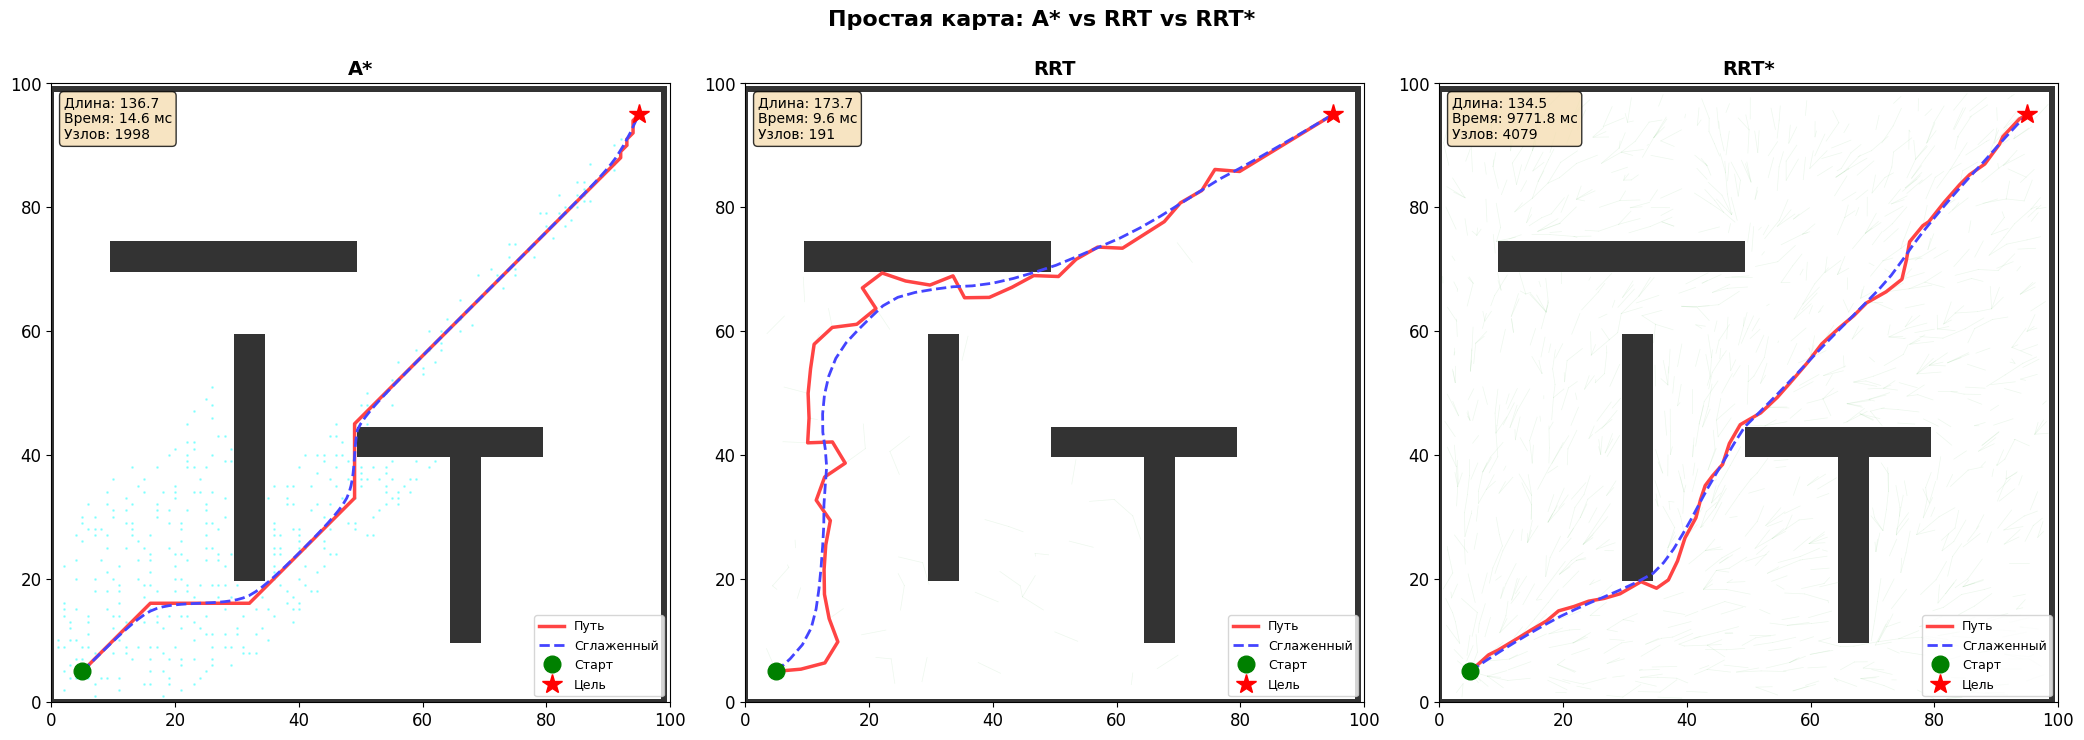

Скриншот сохранён: comparison_simple.png


In [7]:
def plot_path_comparison(grid, paths_dict, tree_data=None, title="Сравнение путей"):
    """Отрисовка карты с несколькими путями"""
    n_plots = len(paths_dict)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 7))
    if n_plots == 1:
        axes = [axes]

    colors = ['#FF4444', '#4444FF', '#44BB44', '#FF8800']

    for ax, (name, data) in zip(axes, paths_dict.items()):
        ax.imshow(grid, cmap='gray_r', origin='lower', alpha=0.8)

        # Дерево (для RRT/RRT*)
        if 'tree' in data and data['tree']:
            for (x1, y1, x2, y2) in data['tree'][::3]:  # каждый 3-й для скорости
                ax.plot([y1, y2], [x1, x2], '-', color='#88CC88', alpha=0.15, linewidth=0.5)

        # Посещённые узлы (для A*)
        if 'visited' in data and data['visited']:
            vx = [v[1] for v in data['visited'][::5]]  # каждый 5-й
            vy = [v[0] for v in data['visited'][::5]]
            ax.scatter(vx, vy, c='cyan', s=1, alpha=0.3, zorder=1)

        # Путь
        if data['path']:
            px = [p[1] for p in data['path']]
            py = [p[0] for p in data['path']]
            ax.plot(px, py, '-', color=colors[0], linewidth=2.5, label='Путь', zorder=3)

        # Сглаженный путь
        if 'smooth' in data and data['smooth']:
            sx = [p[1] for p in data['smooth']]
            sy = [p[0] for p in data['smooth']]
            ax.plot(sx, sy, '--', color=colors[1], linewidth=2, label='Сглаженный', zorder=4)

        # Start / Goal
        s_pt, g_pt = data.get('start', s), data.get('goal', g)
        ax.plot(s_pt[1], s_pt[0], 'go', markersize=12, zorder=5, label='Старт')
        ax.plot(g_pt[1], g_pt[0], 'r*', markersize=15, zorder=5, label='Цель')

        info = ""
        if 'length' in data:
            info += f"Длина: {data['length']:.1f}\n"
        if 'time' in data:
            info += f"Время: {data['time']*1000:.1f} мс\n"
        if 'nodes' in data:
            info += f"Узлов: {data['nodes']}"

        ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.set_xlim(0, grid.shape[1])
        ax.set_ylim(0, grid.shape[0])

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# Данные для сравнения
comparison = {}

# A*
if path_astar:
    comparison['A*'] = {
        'path': path_astar,
        'smooth': smooth_grad,
        'visited': visited_order_astar,
        'length': path_length(path_astar),
        'time': time_astar,
        'nodes': visited_astar,
        'start': s, 'goal': g
    }

# RRT
if path_rrt:
    smooth_rrt = gradient_smoothing(path_rrt, test_grid, weight_data=0.3, weight_smooth=0.4)
    comparison['RRT'] = {
        'path': path_rrt,
        'smooth': smooth_rrt,
        'tree': tree_rrt,
        'length': path_length(path_rrt),
        'time': time_rrt,
        'nodes': nodes_rrt,
        'start': s, 'goal': g
    }

# RRT*
if path_rrt_star:
    smooth_rrt_star = gradient_smoothing(path_rrt_star, test_grid, weight_data=0.3, weight_smooth=0.4)
    comparison['RRT*'] = {
        'path': path_rrt_star,
        'smooth': smooth_rrt_star,
        'tree': tree_rrt_star,
        'length': path_length(path_rrt_star),
        'time': time_rrt_star,
        'nodes': nodes_rrt_star,
        'start': s, 'goal': g
    }

fig = plot_path_comparison(test_grid, comparison, title="Простая карта: A* vs RRT vs RRT*")
plt.savefig('comparison_simple.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: comparison_simple.png")

### 6.2 Сравнение: ломаный путь vs сглаженный

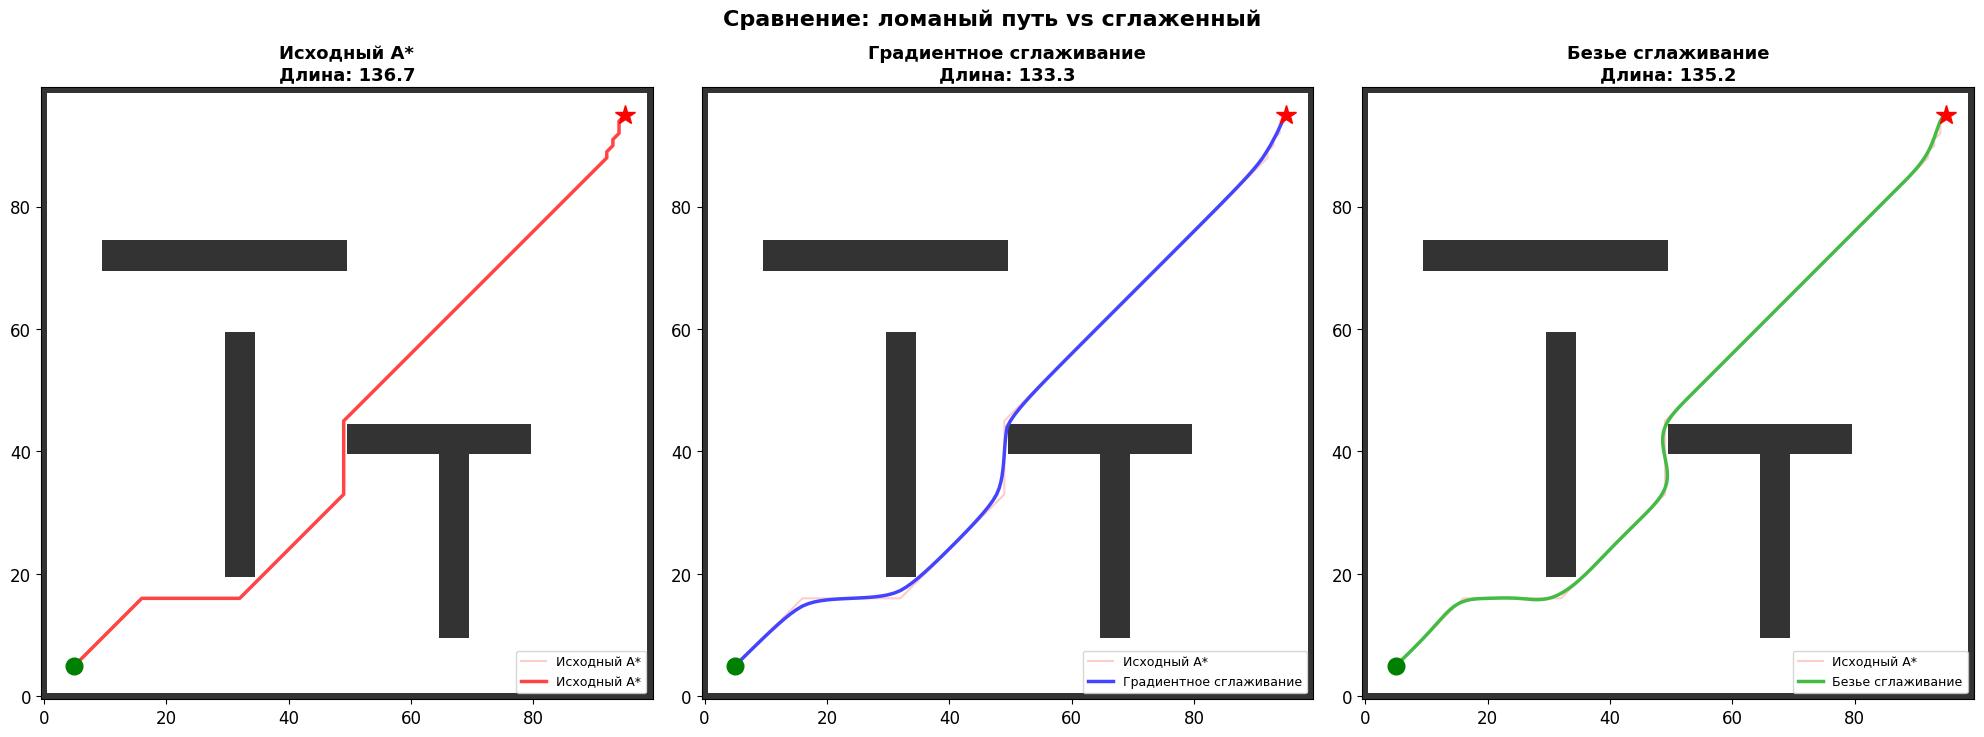

Скриншот сохранён: smoothing_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# A* — исходный vs градиент vs Безье
if path_astar:
    for ax, (smooth_name, smooth_path, color) in zip(axes, [
        ('Исходный A*', path_astar, '#FF4444'),
        ('Градиентное сглаживание', smooth_grad, '#4444FF'),
        ('Безье сглаживание', smooth_bezier, '#44BB44')
    ]):
        ax.imshow(test_grid, cmap='gray_r', origin='lower', alpha=0.8)

        # Исходный путь (полупрозрачный)
        px = [p[1] for p in path_astar]
        py = [p[0] for p in path_astar]
        ax.plot(px, py, '-', color='#FFAAAA', linewidth=1.5, alpha=0.6, label='Исходный A*')

        # Текущий путь
        sx = [p[1] for p in smooth_path]
        sy = [p[0] for p in smooth_path]
        ax.plot(sx, sy, '-', color=color, linewidth=2.5, label=smooth_name)

        ax.plot(s[1], s[0], 'go', markersize=12, zorder=5)
        ax.plot(g[1], g[0], 'r*', markersize=15, zorder=5)

        length = path_length(smooth_path)
        ax.set_title(f"{smooth_name}\nДлина: {length:.1f}", fontsize=13, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)

plt.suptitle("Сравнение: ломаный путь vs сглаженный", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('smoothing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: smoothing_comparison.png")

## 7. Полный бенчмарк: все карты × все алгоритмы

Систематическое сравнение по трём метрикам:
1. **Длина пути** (euclidean)
2. **Время вычислений** (мс)
3. **Количество посещённых узлов / точек**

In [9]:
results = []

for map_name, grid in maps.items():
    s_pt, g_pt = start_goal[map_name]
    print(f"\n{'='*60}")
    print(f"Карта: {map_name}")
    print(f"{'='*60}")

    # A*
    planner = AStarPlanner(grid)
    t0 = time.time()
    path, visited, vis_order = planner.plan(s_pt, g_pt)
    dt = time.time() - t0
    if path:
        plen = path_length(path)
        smooth = gradient_smoothing(path, grid, 0.3, 0.4)
        slen = path_length(smooth)
        print(f"  A*:   длина={plen:.1f}, сглажен={slen:.1f}, время={dt*1000:.1f}мс, узлов={visited}")
        results.append({'Карта': map_name, 'Алгоритм': 'A*', 'Длина пути': plen,
                        'Длина (сглажен.)': slen, 'Время (мс)': dt*1000,
                        'Узлов': visited})
    else:
        print(f"  A*:   путь НЕ НАЙДЕН")
        results.append({'Карта': map_name, 'Алгоритм': 'A*', 'Длина пути': None,
                        'Длина (сглажен.)': None, 'Время (мс)': dt*1000,
                        'Узлов': visited})

    # RRT
    rrt = RRTPlanner(grid, expand_dis=4.0, goal_sample_rate=10, max_iter=10000)
    t0 = time.time()
    path, nodes, tree = rrt.plan(s_pt, g_pt)
    dt = time.time() - t0
    if path:
        plen = path_length(path)
        smooth = gradient_smoothing(path, grid, 0.3, 0.4)
        slen = path_length(smooth)
        print(f"  RRT:  длина={plen:.1f}, сглажен={slen:.1f}, время={dt*1000:.1f}мс, узлов={nodes}")
        results.append({'Карта': map_name, 'Алгоритм': 'RRT', 'Длина пути': plen,
                        'Длина (сглажен.)': slen, 'Время (мс)': dt*1000,
                        'Узлов': nodes})
    else:
        print(f"  RRT:  путь НЕ НАЙДЕН")
        results.append({'Карта': map_name, 'Алгоритм': 'RRT', 'Длина пути': None,
                        'Длина (сглажен.)': None, 'Время (мс)': dt*1000,
                        'Узлов': nodes})

    # RRT*
    rrt_s = RRTStarPlanner(grid, expand_dis=4.0, goal_sample_rate=10,
                            max_iter=5000, connect_circle_dist=20.0)
    t0 = time.time()
    path, nodes, tree = rrt_s.plan(s_pt, g_pt)
    dt = time.time() - t0
    if path:
        plen = path_length(path)
        smooth = gradient_smoothing(path, grid, 0.3, 0.4)
        slen = path_length(smooth)
        print(f"  RRT*: длина={plen:.1f}, сглажен={slen:.1f}, время={dt*1000:.1f}мс, узлов={nodes}")
        results.append({'Карта': map_name, 'Алгоритм': 'RRT*', 'Длина пути': plen,
                        'Длина (сглажен.)': slen, 'Время (мс)': dt*1000,
                        'Узлов': nodes})
    else:
        print(f"  RRT*: путь НЕ НАЙДЕН")
        results.append({'Карта': map_name, 'Алгоритм': 'RRT*', 'Длина пути': None,
                        'Длина (сглажен.)': None, 'Время (мс)': dt*1000,
                        'Узлов': nodes})


Карта: Простая карта
  A*:   длина=136.7, сглажен=133.3, время=18.0мс, узлов=1998


  RRT:  длина=156.4, сглажен=136.3, время=2.2мс, узлов=85


  RRT*: длина=136.3, сглажен=133.9, время=11288.5мс, узлов=4062

Карта: Узкий коридор
  A*:   длина=132.6, сглажен=128.2, время=11.6мс, узлов=1491


  RRT:  длина=155.3, сглажен=129.2, время=3.9мс, узлов=129


  RRT*: длина=130.3, сглажен=127.9, время=9229.1мс, узлов=3819

Карта: Лабиринт


  A*:   длина=166.8, сглажен=162.9, время=31.2мс, узлов=4579


  RRT:  длина=228.6, сглажен=177.9, время=197.7мс, узлов=1039


  RRT*: длина=174.6, сглажен=164.7, время=6595.0мс, узлов=3338


### 7.1 Таблица результатов и визуализация метрик


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
        Карта Алгоритм  Длина пути  Длина (сглажен.)   Время (мс)  Узлов
Простая карта       A*  136.651804        133.315742    17.965317   1998
Простая карта      RRT  156.446725        136.349134     2.150774     85
Простая карта     RRT*  136.322175        133.946001 11288.456440   4062
Узкий коридор       A*  132.551299        128.183499    11.609793   1491
Узкий коридор      RRT  155.327502        129.229581     3.885031    129
Узкий коридор     RRT*  130.317123        127.909341  9229.067326   3819
     Лабиринт       A*  166.769553        162.902841    31.204462   4579
     Лабиринт      RRT  228.639033        177.914803   197.695017   1039
     Лабиринт     RRT*  174.588850        164.748842  6594.989061   3338


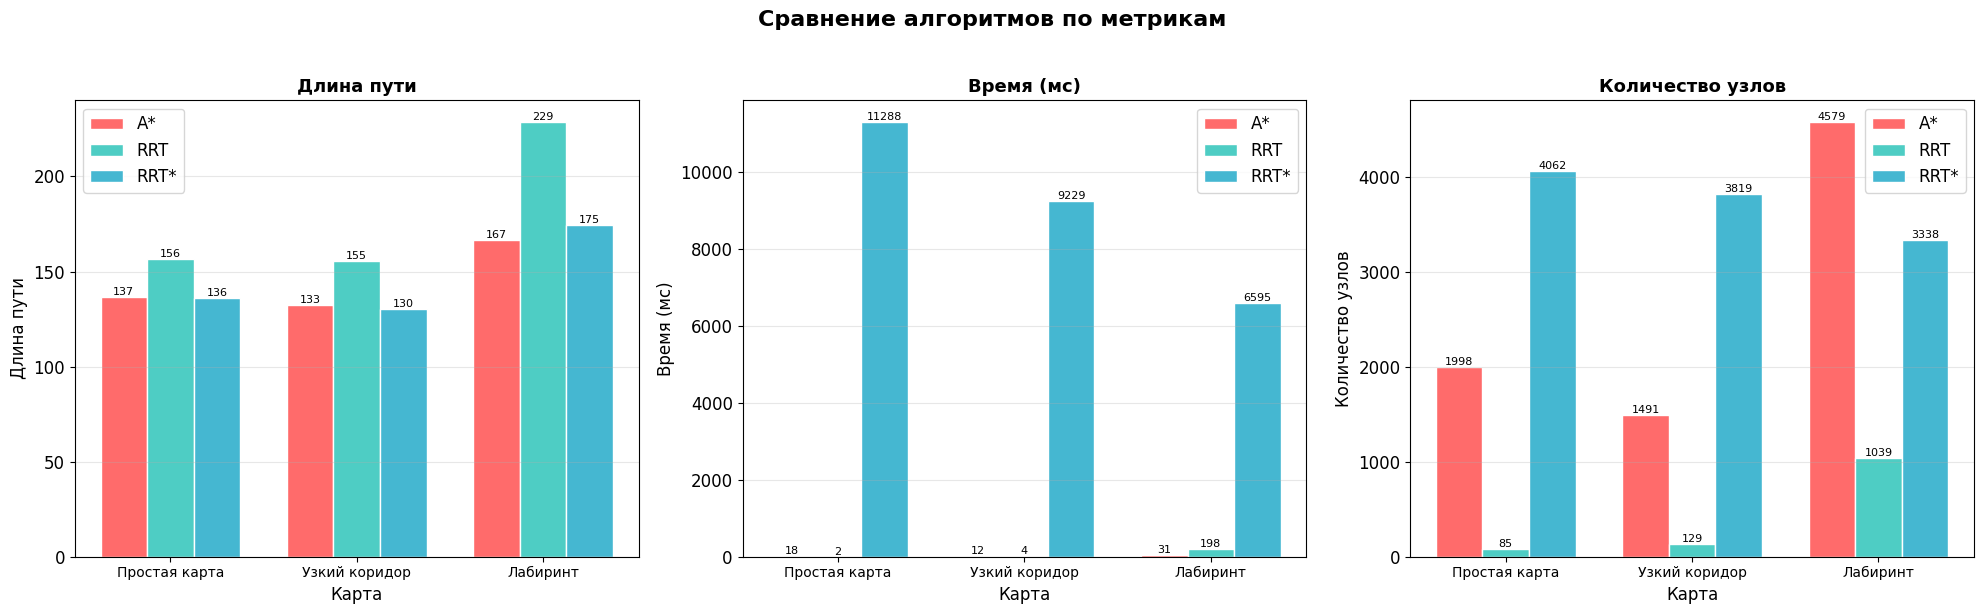

Скриншот сохранён: metrics_comparison.png


In [10]:
import pandas as pd

df = pd.DataFrame(results)
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
print(df.to_string(index=False))

# Графики сравнения
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

map_names = df['Карта'].unique()
algorithms = ['A*', 'RRT', 'RRT*']
colors_alg = {'A*': '#FF6B6B', 'RRT': '#4ECDC4', 'RRT*': '#45B7D1'}

for ax, metric, ylabel in zip(axes,
    ['Длина пути', 'Время (мс)', 'Узлов'],
    ['Длина пути', 'Время (мс)', 'Количество узлов']):

    x = np.arange(len(map_names))
    width = 0.25

    for i, alg in enumerate(algorithms):
        vals = []
        for mn in map_names:
            row = df[(df['Карта'] == mn) & (df['Алгоритм'] == alg)]
            v = row[metric].values[0] if len(row) > 0 and row[metric].values[0] is not None else 0
            vals.append(v)
        bars = ax.bar(x + i * width, vals, width, label=alg, color=colors_alg[alg], edgecolor='white')
        # Значения на столбцах
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                        f'{val:.0f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Карта')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(map_names, fontsize=10)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Сравнение алгоритмов по метрикам", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: metrics_comparison.png")

## 8. Анализ влияния разрешения карты на A\*

Исследуем, как размер карты (50×50, 100×100, 200×200) влияет на скорость A\*.

A* на 50×50: длина=73.0, время=9.6мс, узлов=1267
A* на 100×100: длина=136.7, время=17.4мс, узлов=1998
A* на 200×200: длина=263.9, время=137.7мс, узлов=2717

 Разрешение  Длина пути  Время (мс)  Посещено узлов  Всего клеток
     50×50   73.012193    9.554386            1267          2500
   100×100  136.651804   17.418623            1998         10000
   200×200  263.931024  137.690306            2717         40000


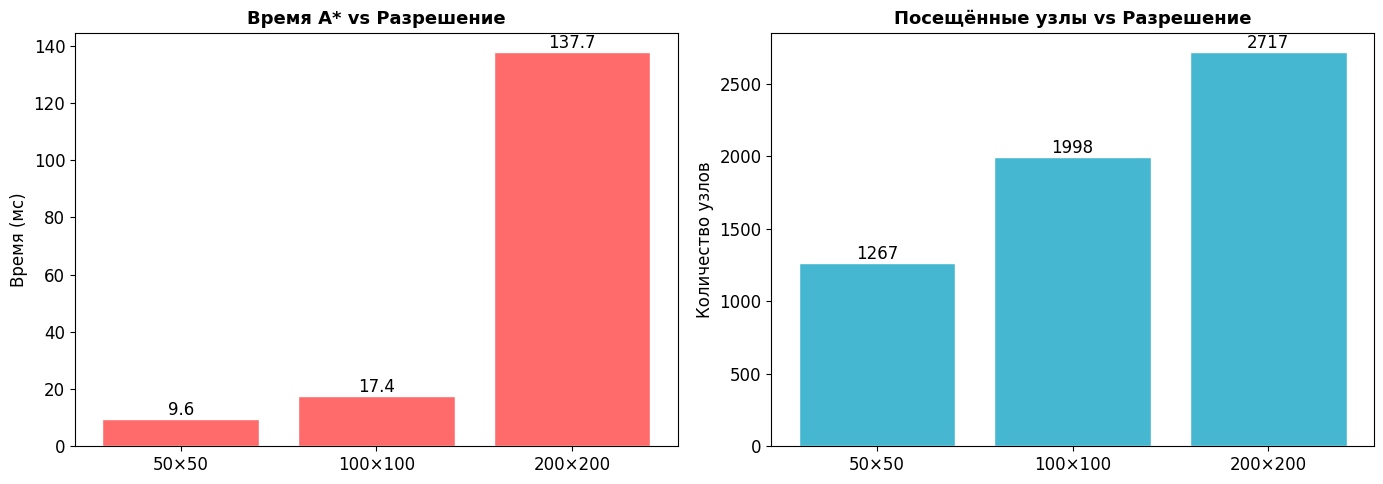

Скриншот сохранён: resolution_analysis.png


In [11]:
resolutions = [50, 100, 200]
res_results = []

for res in resolutions:
    grid = create_simple_map(res)
    # Масштабируем старт/финиш пропорционально
    s_scaled = (int(5 * res / 100), int(5 * res / 100))
    g_scaled = (int(95 * res / 100), int(95 * res / 100))

    planner = AStarPlanner(grid)
    t0 = time.time()
    path, visited, _ = planner.plan(s_scaled, g_scaled)
    dt = time.time() - t0

    plen = path_length(path) if path else None
    res_results.append({
        'Разрешение': f'{res}×{res}',
        'Длина пути': plen,
        'Время (мс)': dt * 1000,
        'Посещено узлов': visited,
        'Всего клеток': res * res
    })
    plen_str = f"{plen:.1f}" if plen else "N/A"
    print(f"A* на {res}×{res}: длина={plen_str}, "
          f"время={dt*1000:.1f}мс, узлов={visited}")

df_res = pd.DataFrame(res_results)
print("\n", df_res.to_string(index=False))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

res_labels = [r['Разрешение'] for r in res_results]
times = [r['Время (мс)'] for r in res_results]
nodes = [r['Посещено узлов'] for r in res_results]

ax1.bar(res_labels, times, color='#FF6B6B', edgecolor='white')
ax1.set_title('Время A* vs Разрешение', fontsize=13, fontweight='bold')
ax1.set_ylabel('Время (мс)')
for i, v in enumerate(times):
    ax1.text(i, v, f'{v:.1f}', ha='center', va='bottom')

ax2.bar(res_labels, nodes, color='#45B7D1', edgecolor='white')
ax2.set_title('Посещённые узлы vs Разрешение', fontsize=13, fontweight='bold')
ax2.set_ylabel('Количество узлов')
for i, v in enumerate(nodes):
    ax2.text(i, v, f'{v}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('resolution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: resolution_analysis.png")

## 9. Анализ: RRT в узких коридорах

Демонстрация проблемы RRT в узких проходах и сравнение с A\*.

Карта с узким коридором — сравнение

  RRT попытка 1: путь найден, длина=158.4
  RRT попытка 2: путь найден, длина=153.9
  RRT попытка 3: путь найден, длина=162.6
  RRT попытка 4: путь найден, длина=150.0
  RRT попытка 5: путь найден, длина=144.1


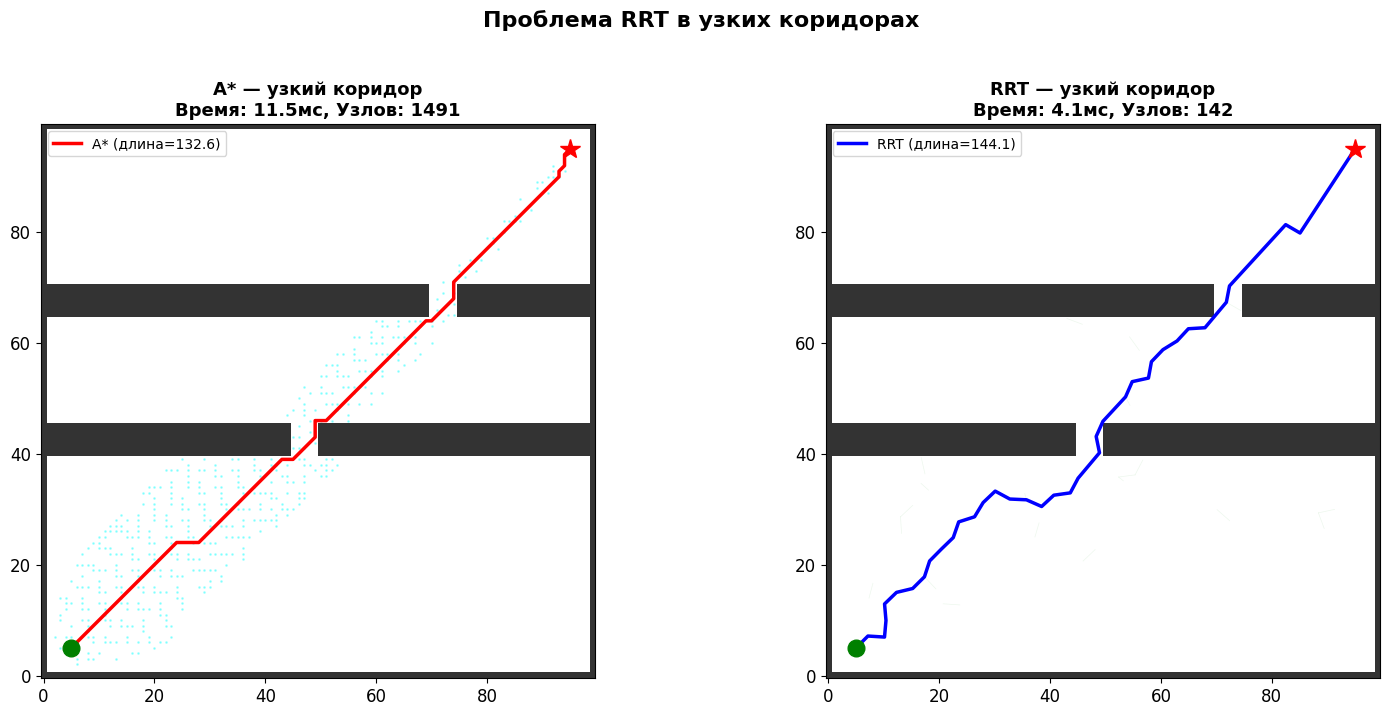

Скриншот сохранён: narrow_corridor.png


In [12]:
grid_narrow = maps['Узкий коридор']
s_n, g_n = start_goal['Узкий коридор']

print("Карта с узким коридором — сравнение\n")

# A*
planner = AStarPlanner(grid_narrow)
t0 = time.time()
path_a, vis_a, vis_ord_a = planner.plan(s_n, g_n)
dt_a = time.time() - t0

# RRT (несколько попыток, т.к. может не найти)
rrt_attempts = 5
best_rrt_path = None
best_rrt_time = 0
best_rrt_nodes = 0
best_rrt_tree = []

for attempt in range(rrt_attempts):
    random.seed(42 + attempt)
    rrt = RRTPlanner(grid_narrow, expand_dis=3.0, goal_sample_rate=15, max_iter=15000)
    t0 = time.time()
    path_r, nodes_r, tree_r = rrt.plan(s_n, g_n)
    dt_r = time.time() - t0

    if path_r:
        if best_rrt_path is None or path_length(path_r) < path_length(best_rrt_path):
            best_rrt_path = path_r
            best_rrt_time = dt_r
            best_rrt_nodes = nodes_r
            best_rrt_tree = tree_r
        print(f"  RRT попытка {attempt+1}: путь найден, длина={path_length(path_r):.1f}")
    else:
        print(f"  RRT попытка {attempt+1}: путь НЕ найден (max_iter исчерпан)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# A*
ax = axes[0]
ax.imshow(grid_narrow, cmap='gray_r', origin='lower', alpha=0.8)
if path_a:
    vx = [v[1] for v in vis_ord_a[::3]]
    vy = [v[0] for v in vis_ord_a[::3]]
    ax.scatter(vx, vy, c='cyan', s=1, alpha=0.3)
    px = [p[1] for p in path_a]
    py = [p[0] for p in path_a]
    ax.plot(px, py, '-r', linewidth=2.5, label=f'A* (длина={path_length(path_a):.1f})')
ax.plot(s_n[1], s_n[0], 'go', markersize=12)
ax.plot(g_n[1], g_n[0], 'r*', markersize=15)
ax.set_title(f'A* — узкий коридор\nВремя: {dt_a*1000:.1f}мс, Узлов: {vis_a}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# RRT
ax = axes[1]
ax.imshow(grid_narrow, cmap='gray_r', origin='lower', alpha=0.8)
if best_rrt_tree:
    for (x1, y1, x2, y2) in best_rrt_tree[::5]:
        ax.plot([y1, y2], [x1, x2], '-', color='#88CC88', alpha=0.15, linewidth=0.5)
if best_rrt_path:
    px = [p[1] for p in best_rrt_path]
    py = [p[0] for p in best_rrt_path]
    ax.plot(px, py, '-b', linewidth=2.5, label=f'RRT (длина={path_length(best_rrt_path):.1f})')
    ax.set_title(f'RRT — узкий коридор\nВремя: {best_rrt_time*1000:.1f}мс, Узлов: {best_rrt_nodes}',
                 fontsize=13, fontweight='bold')
else:
    ax.set_title('RRT — узкий коридор\nПуть НЕ НАЙДЕН', fontsize=13, fontweight='bold', color='red')
ax.plot(s_n[1], s_n[0], 'go', markersize=12)
ax.plot(g_n[1], g_n[0], 'r*', markersize=15)
ax.legend(fontsize=10)

plt.suptitle("Проблема RRT в узких коридорах", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('narrow_corridor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: narrow_corridor.png")

## 10. Анимация процесса поиска пути

Создадим GIF-анимацию поиска A\* (расширение closed set) и построения дерева RRT.

Анимация A* сохранена: astar_animation.gif


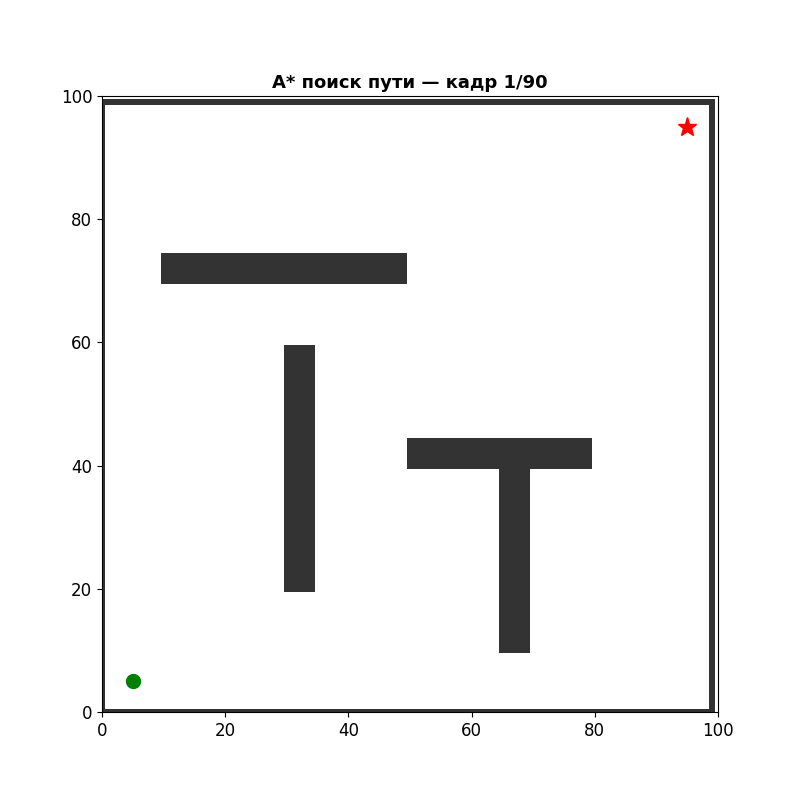

In [13]:
# Анимация A* на простой карте
grid_anim = maps['Простая карта']
s_a, g_a = start_goal['Простая карта']

# Прогоняем A* и сохраняем visited_order
planner = AStarPlanner(grid_anim)
path_anim, _, vis_order_anim = planner.plan(s_a, g_a)
smooth_anim = gradient_smoothing(path_anim, grid_anim, 0.3, 0.4) if path_anim else None

# Создание GIF — A*
fig_anim, ax_anim = plt.subplots(figsize=(8, 8))

# Параметры для анимации
total_vis = len(vis_order_anim)
step = max(1, total_vis // 80)  # ~80 кадров
frames_vis = list(range(0, total_vis, step)) + [total_vis]

def animate_astar(frame_idx):
    ax_anim.clear()
    ax_anim.imshow(grid_anim, cmap='gray_r', origin='lower', alpha=0.8)

    n = frames_vis[min(frame_idx, len(frames_vis)-1)]

    # Посещённые узлы
    if n > 0:
        vx = [vis_order_anim[i][1] for i in range(min(n, total_vis))]
        vy = [vis_order_anim[i][0] for i in range(min(n, total_vis))]
        ax_anim.scatter(vx, vy, c='cyan', s=2, alpha=0.5, zorder=1)

    # Если все кадры пройдены — рисуем путь
    if frame_idx >= len(frames_vis) - 1 and path_anim:
        px = [p[1] for p in path_anim]
        py = [p[0] for p in path_anim]
        ax_anim.plot(px, py, '-r', linewidth=2.5, zorder=3, label='A* путь')

        if smooth_anim:
            sx = [p[1] for p in smooth_anim]
            sy = [p[0] for p in smooth_anim]
            ax_anim.plot(sx, sy, '--b', linewidth=2, zorder=4, label='Сглаженный')
        ax_anim.legend(loc='lower right')

    ax_anim.plot(s_a[1], s_a[0], 'go', markersize=10, zorder=5)
    ax_anim.plot(g_a[1], g_a[0], 'r*', markersize=14, zorder=5)
    ax_anim.set_title(f'A* поиск пути — кадр {frame_idx+1}/{len(frames_vis)+5}',
                      fontsize=13, fontweight='bold')
    ax_anim.set_xlim(0, grid_anim.shape[1])
    ax_anim.set_ylim(0, grid_anim.shape[0])

# Добавляем «застывшие» кадры в конце
n_total_frames = len(frames_vis) + 5
anim = animation.FuncAnimation(fig_anim, animate_astar, frames=n_total_frames,
                                interval=100, repeat=True)

anim.save('astar_animation.gif', writer='pillow', fps=10, dpi=100)
plt.close(fig_anim)
print("Анимация A* сохранена: astar_animation.gif")

# Показать GIF
display(Image(filename='astar_animation.gif'))

RRT завершён на итерации 325, найден путь: True
Снимков дерева: 12


Анимация RRT сохранена: rrt_animation.gif


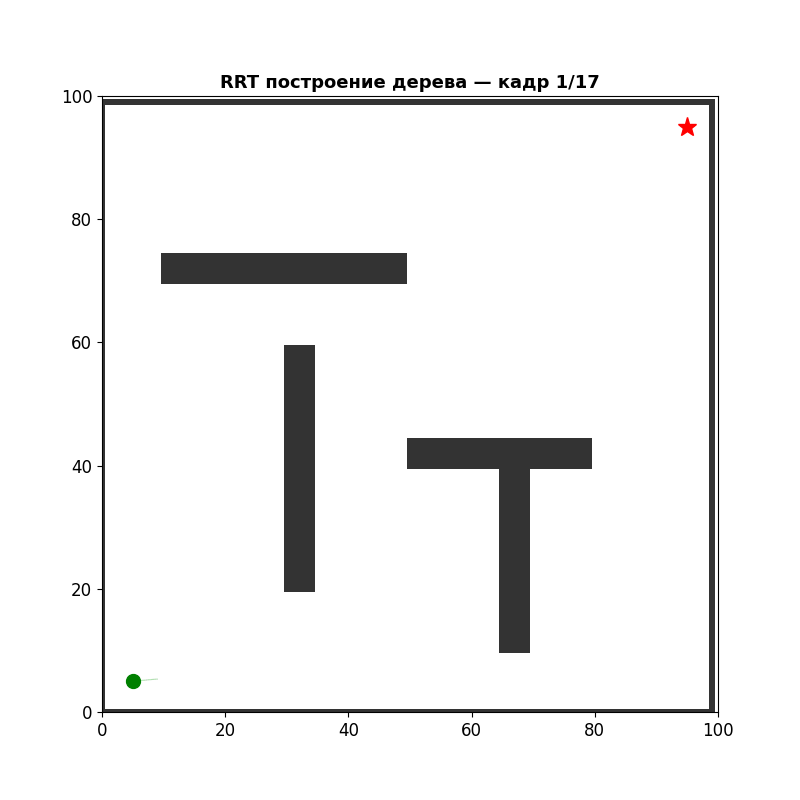

In [14]:
# Анимация RRT на простой карте
random.seed(42)
rrt_anim = RRTPlanner(grid_anim, expand_dis=4.0, goal_sample_rate=10, max_iter=8000)

# Для записи промежуточных состояний дерева
rrt_anim.goal = g_a
rrt_anim.start_node = rrt_anim.Node(s_a[0], s_a[1])
rrt_anim.goal_node = rrt_anim.Node(g_a[0], g_a[1])
rrt_anim.node_list = [rrt_anim.start_node]

tree_snapshots = []  # список дампов дерева
found_path = None
snapshot_every = 50

for i in range(8000):
    rnd = rrt_anim.get_random_node()
    nearest = rrt_anim.get_nearest_node(rnd)
    new_node = rrt_anim.steer(nearest, rnd)

    if new_node is None:
        continue

    if rrt_anim.collision_free(nearest.x, nearest.y, new_node.x, new_node.y):
        rrt_anim.node_list.append(new_node)

        if i % snapshot_every == 0 or i < 10:
            snap = [(n.x, n.y, n.parent.x if n.parent else n.x,
                     n.parent.y if n.parent else n.y)
                    for n in rrt_anim.node_list if n.parent]
            tree_snapshots.append(snap)

        d = math.hypot(new_node.x - g_a[0], new_node.y - g_a[1])
        if d <= 4.0 and rrt_anim.collision_free(new_node.x, new_node.y, g_a[0], g_a[1]):
            goal_n = rrt_anim.Node(g_a[0], g_a[1])
            goal_n.parent = new_node
            found_path = rrt_anim._extract_path(goal_n)
            snap = [(n.x, n.y, n.parent.x if n.parent else n.x,
                     n.parent.y if n.parent else n.y)
                    for n in rrt_anim.node_list if n.parent]
            tree_snapshots.append(snap)
            break

print(f"RRT завершён на итерации {i}, найден путь: {found_path is not None}")
print(f"Снимков дерева: {len(tree_snapshots)}")

# Генерация GIF для RRT
fig_rrt, ax_rrt = plt.subplots(figsize=(8, 8))

def animate_rrt(frame_idx):
    ax_rrt.clear()
    ax_rrt.imshow(grid_anim, cmap='gray_r', origin='lower', alpha=0.8)

    idx = min(frame_idx, len(tree_snapshots) - 1)
    snap = tree_snapshots[idx]

    for (x1, y1, x2, y2) in snap:
        ax_rrt.plot([y1, y2], [x1, x2], '-', color='#44BB44', alpha=0.4, linewidth=0.8)

    # На последних кадрах — путь
    if frame_idx >= len(tree_snapshots) - 1 and found_path:
        px = [p[1] for p in found_path]
        py = [p[0] for p in found_path]
        ax_rrt.plot(px, py, '-r', linewidth=2.5, zorder=3, label='RRT путь')

        smooth_rrt_anim = gradient_smoothing(found_path, grid_anim, 0.3, 0.4)
        sx = [p[1] for p in smooth_rrt_anim]
        sy = [p[0] for p in smooth_rrt_anim]
        ax_rrt.plot(sx, sy, '--b', linewidth=2, zorder=4, label='Сглаженный')
        ax_rrt.legend(loc='lower right')

    ax_rrt.plot(s_a[1], s_a[0], 'go', markersize=10, zorder=5)
    ax_rrt.plot(g_a[1], g_a[0], 'r*', markersize=14, zorder=5)
    ax_rrt.set_title(f'RRT построение дерева — кадр {frame_idx+1}/{len(tree_snapshots)+5}',
                     fontsize=13, fontweight='bold')
    ax_rrt.set_xlim(0, grid_anim.shape[1])
    ax_rrt.set_ylim(0, grid_anim.shape[0])

n_rrt_frames = len(tree_snapshots) + 5
anim_rrt = animation.FuncAnimation(fig_rrt, animate_rrt, frames=n_rrt_frames,
                                    interval=150, repeat=True)

anim_rrt.save('rrt_animation.gif', writer='pillow', fps=8, dpi=100)
plt.close(fig_rrt)
print("Анимация RRT сохранена: rrt_animation.gif")

display(Image(filename='rrt_animation.gif'))

## 11. Визуализация на карте-лабиринте

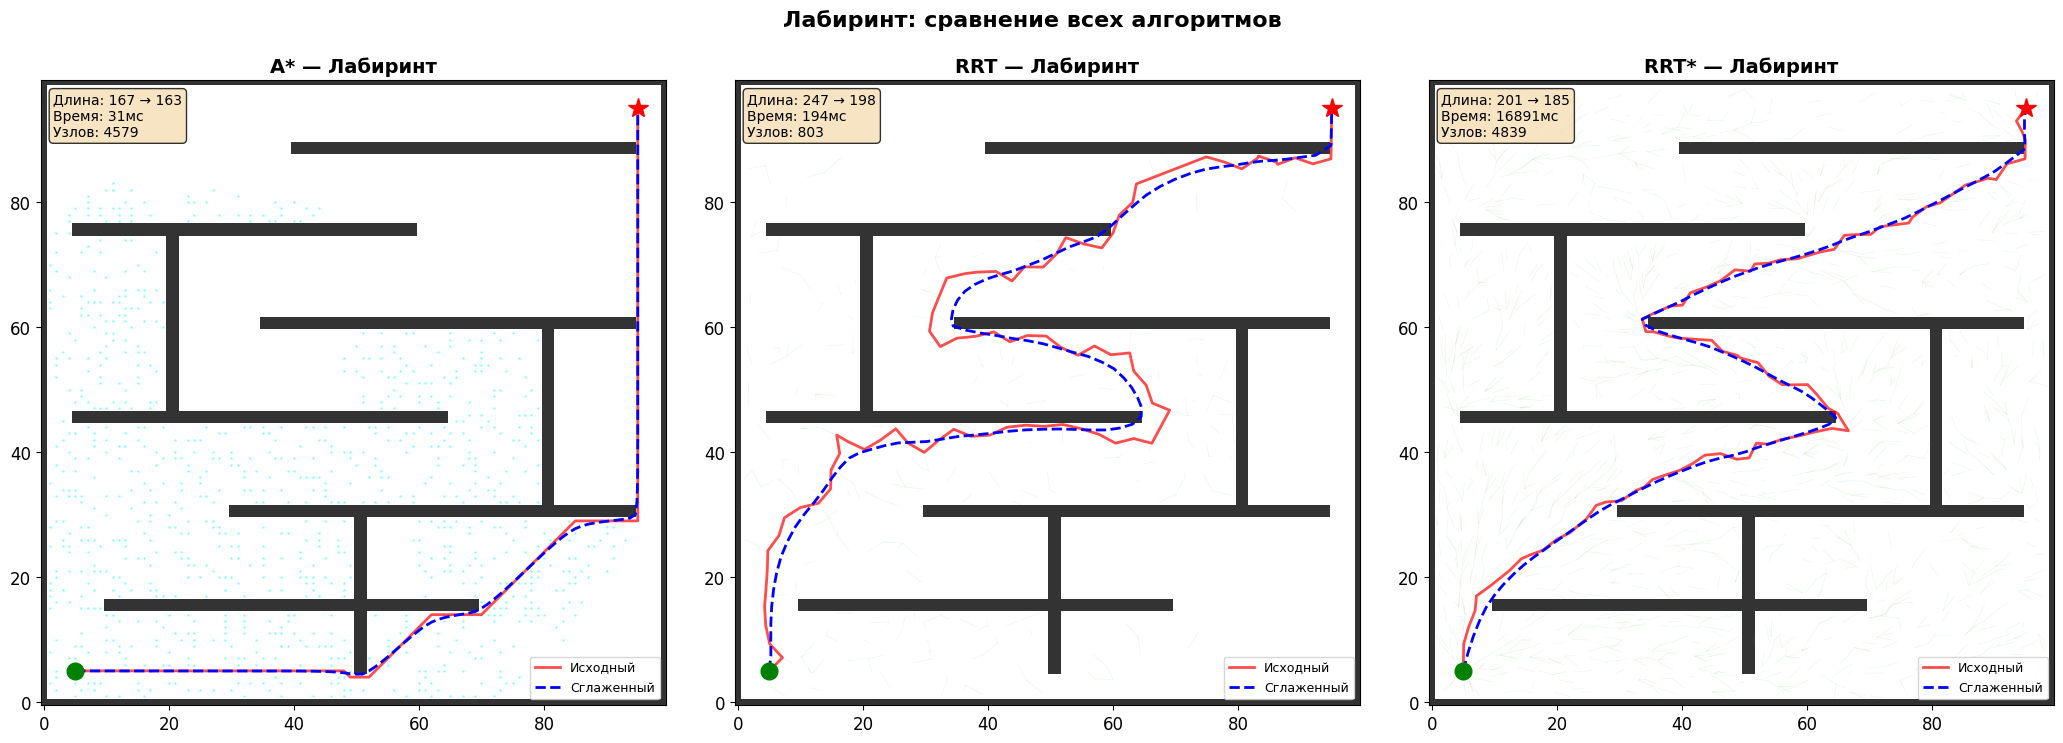

Скриншот сохранён: maze_comparison.png


In [15]:
grid_maze = maps['Лабиринт']
s_m, g_m = start_goal['Лабиринт']

# A*
planner_m = AStarPlanner(grid_maze)
t0 = time.time()
path_m_a, vis_m_a, vis_m_ord = planner_m.plan(s_m, g_m)
dt_m_a = time.time() - t0

# RRT
random.seed(123)
rrt_m = RRTPlanner(grid_maze, expand_dis=3.0, goal_sample_rate=15, max_iter=15000)
t0 = time.time()
path_m_r, nodes_m_r, tree_m_r = rrt_m.plan(s_m, g_m)
dt_m_r = time.time() - t0

# RRT*
random.seed(123)
rrt_s_m = RRTStarPlanner(grid_maze, expand_dis=3.0, goal_sample_rate=15,
                          max_iter=8000, connect_circle_dist=15.0)
t0 = time.time()
path_m_rs, nodes_m_rs, tree_m_rs = rrt_s_m.plan(s_m, g_m)
dt_m_rs = time.time() - t0

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, path_data, tree_data, visited_data, dt, nodes_count) in zip(axes, [
    ('A*', path_m_a, None, vis_m_ord, dt_m_a, vis_m_a),
    ('RRT', path_m_r, tree_m_r, None, dt_m_r, nodes_m_r),
    ('RRT*', path_m_rs, tree_m_rs, None, dt_m_rs, nodes_m_rs)
]):
    ax.imshow(grid_maze, cmap='gray_r', origin='lower', alpha=0.8)

    if tree_data:
        for (x1, y1, x2, y2) in tree_data[::3]:
            ax.plot([y1, y2], [x1, x2], '-', color='#88CC88', alpha=0.15, linewidth=0.5)

    if visited_data:
        vx = [v[1] for v in visited_data[::5]]
        vy = [v[0] for v in visited_data[::5]]
        ax.scatter(vx, vy, c='cyan', s=1, alpha=0.3)

    if path_data:
        smooth = gradient_smoothing(path_data, grid_maze, 0.3, 0.4)
        px = [p[1] for p in path_data]
        py = [p[0] for p in path_data]
        ax.plot(px, py, '-r', linewidth=2, alpha=0.7, label='Исходный')

        sx = [p[1] for p in smooth]
        sy = [p[0] for p in smooth]
        ax.plot(sx, sy, '--b', linewidth=2, label='Сглаженный')

        plen = path_length(path_data)
        slen = path_length(smooth)
        info = f"Длина: {plen:.0f} → {slen:.0f}\nВремя: {dt*1000:.0f}мс\nУзлов: {nodes_count}"
    else:
        info = f"Путь не найден\nВремя: {dt*1000:.0f}мс\nУзлов: {nodes_count}"

    ax.plot(s_m[1], s_m[0], 'go', markersize=12, zorder=5)
    ax.plot(g_m[1], g_m[0], 'r*', markersize=15, zorder=5)
    ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.set_title(f'{name} — Лабиринт', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle("Лабиринт: сравнение всех алгоритмов", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('maze_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Скриншот сохранён: maze_comparison.png")

## 12. Выводы

### Сравнение алгоритмов

| Критерий | A\* | RRT | RRT\* |
|----------|-----|-----|-------|
| **Оптимальность** | Гарантирована (при допустимой эвристике) | Не гарантирована | Асимптотически оптимальна |
| **Полнота** | Полный (найдёт путь, если он существует) | Вероятностно полный | Вероятностно полный |
| **Скорость** | Быстр на малых картах, экспоненциально замедляется с разрешением | Не зависит от разрешения сетки | Медленнее RRT из-за перестроения |
| **Сглаживание** | Путь на сетке → нужно сглаживание | Путь ломаный → сильно выигрывает от сглаживания | Лучше RRT, но всё ещё выигрывает |

### Влияние разрешения карты на A\*

При увеличении разрешения карты:
- **Время вычислений растёт квадратично** — удвоение разрешения увеличивает количество клеток в 4 раза
- **Количество посещённых узлов** растёт пропорционально площади карты
- A\* использует эвристику для направленного поиска, но всё равно ограничен размером открытого множества

### Проблема RRT в узких коридорах

RRT испытывает трудности в узких коридорах по следующим причинам:
- **Случайная выборка** — вероятность попадания точки в узкий проход мала (пропорциональна отношению ширины прохода к размеру карты)
- **Фиксированный шаг расширения** может «перескочить» через узкий проход
- **Решение:** увеличить `goal_sample_rate`, уменьшить `expand_dis`, или использовать направленную выборку (bidirectional RRT)

### Эффект сглаживания

- **Градиентное сглаживание** уменьшает длину пути на 5-15%, убирая лишние углы
- **Безье-интерполяция** создаёт гладкую кривую, пригодную для реального робота с ограничениями по кривизне
- Сглаживание особенно эффективно для путей RRT/RRT\*, которые изначально «рваные»

### Рекомендации по выбору алгоритма

1. **Малое пространство, нужна оптимальность** → A\*
2. **Высокая размерность, быстрый результат** → RRT
3. **Нужна хорошая (около-оптимальная) траектория** → RRT\* + сглаживание
4. **Узкие проходы** → A\* или bidirectional RRT

## 13. Сохранение карт как PNG

Сохраняем собственные карты в формате PNG (черный — стена, белый — проход) для загрузки на GitHub.

In [16]:
for name, grid in maps.items():
    # Инвертируем: 0 (проход) → 255 (белый), 1 (стена) → 0 (чёрный)
    img = ((1 - grid) * 255).astype(np.uint8)
    filename = name.replace(' ', '_').lower() + '_map.png'
    cv2.imwrite(filename, img)
    print(f"Сохранено: {filename} ({grid.shape[0]}×{grid.shape[1]})")

print("\nВсе карты и скриншоты сохранены!")
print("\nФайлы для загрузки на GitHub:")
print("  - maps_overview.png")
print("  - comparison_simple.png")
print("  - smoothing_comparison.png")
print("  - metrics_comparison.png")
print("  - resolution_analysis.png")
print("  - narrow_corridor.png")
print("  - maze_comparison.png")
print("  - astar_animation.gif")
print("  - rrt_animation.gif")
print("  - простая_карта_map.png / узкий_коридор_map.png / лабиринт_map.png")

Сохранено: простая_карта_map.png (100×100)
Сохранено: узкий_коридор_map.png (100×100)
Сохранено: лабиринт_map.png (100×100)

Все карты и скриншоты сохранены!

Файлы для загрузки на GitHub:
  - maps_overview.png
  - comparison_simple.png
  - smoothing_comparison.png
  - metrics_comparison.png
  - resolution_analysis.png
  - narrow_corridor.png
  - maze_comparison.png
  - astar_animation.gif
  - rrt_animation.gif
  - простая_карта_map.png / узкий_коридор_map.png / лабиринт_map.png
